# 04 — Inlet Bellmouth Design

**Purpose:** Design the complete annular inlet assembly consisting of (i) the ISO 5801 outer bellmouth lip, (ii) the semi-ellipsoidal hub centerbody / spinner, and (iii) the upstream settling section with honeycomb and turbulence screen. Evaluate the total-pressure loss budget, turbulence intensity at the rotor face, annular boundary-layer blockage, and locate the ISO 5801 mass-flow measurement plane.

**Inputs:** IGV geometry from notebook 03 (`igv_geometry()` output).

**Outputs:**
- Meridional contours of both stream surfaces
- Loss budget breakdown
- Axial station map (all upstream components referenced to rotor LE)
- Total inlet assembly length

**References:** ISO 5801:2017; Mehta & Bradshaw (1979) Aeronautical J.; Bell & Mehta (1988) NASA CR-177488; Hoerner (1965) Fluid Dynamic Drag.

In [1]:
import sys, pathlib

# Locate repo root (directory that contains src/) regardless of
# where the notebook file sits (repo root or notebooks/ subfolder)
_here = pathlib.Path.cwd()
_root = next(
    (p for p in [_here, *_here.parents] if (p / "src").is_dir()),
    _here,
)
sys.path.insert(0, str(_root))
pathlib.Path(_root / "figures").mkdir(exist_ok=True)


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.igv       import igv_geometry, meanline_with_igv
from src.bellmouth import bellmouth_design, print_bellmouth_summary

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
print('Imports OK')

Imports OK


In [2]:
# ── Load design point from notebook 01 ─────────────────────
import json as _json, pathlib as _pl

_dp_path = _pl.Path(_root / "design_point.json")
if not _dp_path.exists():
    raise FileNotFoundError(
        "design_point.json not found — run notebook 01 first.")

dp = _json.loads(_dp_path.read_text())

# Unpack for convenience
D_TIP = dp["D_tip"]
N_RPM = dp["N_RPM"]
PR    = dp["PR"]
NU    = dp["nu"]
PHI   = dp["phi"]
ETA   = dp["eta_is"]
print(f"Design point: D_tip={D_TIP*1000:.0f} mm  N={N_RPM} RPM  PR={PR}  nu={NU}  phi={PHI}  eta={ETA}")


Design point: D_tip=900 mm  N=3500 RPM  PR=1.1  nu=0.75  phi=0.725  eta=0.85


## 1. Build from IGV design point

In [3]:
igv   = igv_geometry(D_tip=D_TIP, nu=NU, N_RPM=N_RPM, phi=PHI, alpha1_deg=0.0)
rotor = meanline_with_igv(igv, PR=PR, eta_is=ETA)

bell  = bellmouth_design(
    igv,
    contraction_ratio   = 4.0,
    Cd                  = 0.99,
    n_screens           = 1,
    screen_wire_d       = 0.5e-3,
    screen_mesh         = 16.0,
    honeycomb_cell      = 6.35e-3,
    honeycomb_L_D       = 8.0,
    centerbody_fineness = 1.2,
)

print_bellmouth_summary(bell, rotor_dP0_Pa=rotor['dP0_rotor_Pa'])


  ANNULAR BELLMOUTH INLET  —  DESIGN SUMMARY

ANNULUS AT THROAT
────────────────────────────────────────────────────────────
  Casing radius r_tip   : 450.0 mm
  Hub radius r_hub      : 337.5 mm
  Hub-to-tip ratio ν    : 0.750
  Blade height          : 112.5 mm
  Net annular area      : 2783.25 cm²
  Axial velocity Ca     : 104.630 m/s
  Throat Mach number    : 0.30747
  Dynamic pressure q    : 6705.34 Pa

OUTER BELLMOUTH  (ISO 5801 Annex B, elliptical)
────────────────────────────────────────────────────────────
  Lip diameter D_lip    : 1080.0 mm
  Casing diameter D_th  : 900.0 mm
  Radial overhang b     : 90.0 mm  (0.10 × D_th)
  Axial semi-axis a     : 40.5 mm
  a/b                   : 0.450  (ISO 5801 target ~0.45)
  Straight section      : 225.0 mm  (0.25 × D_th)
  Bellmouth total       : 265.5 mm

INNER CENTERBODY  (semi-ellipsoidal spinner)
────────────────────────────────────────────────────────────
  Hub radius (at IGV)   : 337.5 mm
  Max diameter          : 675.0 mm
  Finen

## 2. Meridional contour — both stream surfaces

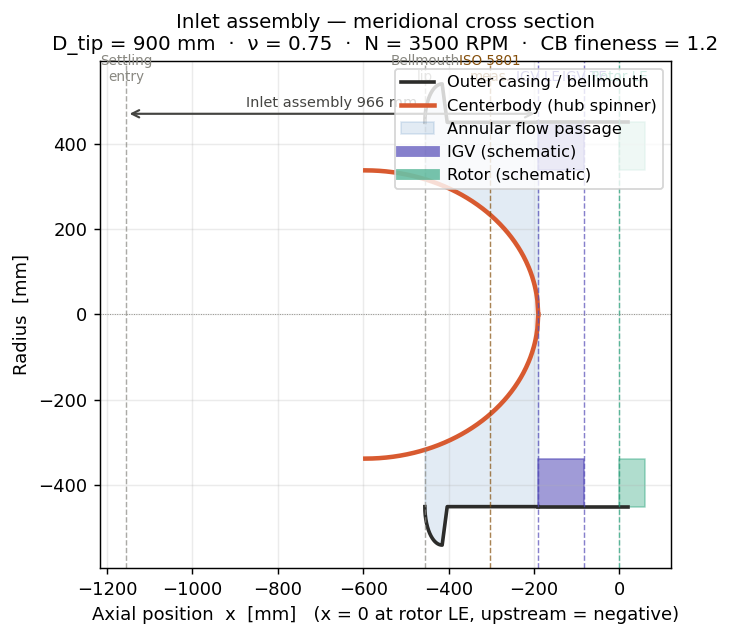

Meridional cross-section plotted OK
  Outer contour : 219 points
  CB contour    : 200 points
  Shared fill   : 600 points  (interpolated — no size mismatch)


In [6]:
# Cell 4 — fixed: bellmouth cross-section (meridional view)
#
# Root cause of the original ValueError:
#   outer_bellmouth_profile() returns 219 points (200 arc + 19 straight after [1:] concat)
#   centerbody_profile()      returns 200 points
#   fill_between(x_cb, r_cb, r_outer) fails because 200 ≠ 219
#
# Fix: build a shared x-axis in rig coordinates (mm, x=0 at rotor LE)
#      and interpolate both contours onto it before calling fill_between.

import numpy as np
import matplotlib.pyplot as plt
from src.igv import igv_geometry
from src.bellmouth import bellmouth_design, outer_bellmouth_profile, centerbody_profile

# ── Geometry ────────────────────────────────────────────────────
igv  = igv_geometry(D_tip=0.900, nu=0.75, N_RPM=3500, phi=0.725, alpha1_deg=0.0)
bell = bellmouth_design(igv)

r_tip = igv['r_tip_mm'] / 1000   # m
r_hub = igv['r_hub_mm'] / 1000   # m

# ── Outer bellmouth in rig coordinates [mm] ─────────────────────
# Local x=0 at lip apex; rig x = x_bell_entry + local_x
outer       = outer_bellmouth_profile(r_tip)
x_outer_rig = bell['x_bell_entry_mm'] + outer['x_contour'] * 1000   # mm
r_outer_mm  = outer['r_contour'] * 1000                              # mm

# ── Centerbody in rig coordinates [mm] ──────────────────────────
# Local x=0 at nose tip; rig x = x_cb_nose + local_x
cb          = centerbody_profile(r_hub, fineness=1.2)
x_cb_rig    = bell['x_cb_nose_tip_mm'] + cb['x_contour'] * 1000     # mm
r_cb_mm     = cb['r_contour'] * 1000                                 # mm

# ── Shared x-grid over the axial overlap region ─────────────────
# fill_between requires all three arrays (x, y1, y2) to have the same length.
# Interpolate both contours onto a single dense common grid.
x_fill_lo = max(x_outer_rig[0],  x_cb_rig[0])    # later start
x_fill_hi = min(x_outer_rig[-1], x_cb_rig[-1])   # earlier end
x_common  = np.linspace(x_fill_lo, x_fill_hi, 600)

r_outer_interp = np.interp(x_common, x_outer_rig, r_outer_mm)
r_cb_interp    = np.interp(x_common, x_cb_rig,    r_cb_mm)

# ── Plot ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

# Outer casing wall (both sides for symmetry)
ax.plot(x_outer_rig,  r_outer_mm, color='#2C2C2A', lw=2,   label='Outer casing / bellmouth')
ax.plot(x_outer_rig, -r_outer_mm, color='#2C2C2A', lw=2)

# Centerbody (both sides)
ax.plot(x_cb_rig,  r_cb_mm, color='#D85A30', lw=2.5, label='Centerbody (hub spinner)')
ax.plot(x_cb_rig, -r_cb_mm, color='#D85A30', lw=2.5)

# Annular flow passage — shared grid avoids size mismatch
ax.fill_between(x_common,  r_cb_interp,  r_outer_interp,  alpha=0.12, color='#185FA5', label='Annular flow passage')
ax.fill_between(x_common, -r_outer_interp, -r_cb_interp,  alpha=0.12, color='#185FA5')

# Straight casing run between bellmouth exit and rotor (constant radius)
x_straight = np.array([bell['x_bell_exit_mm'], 20.0])   # bell exit to a little past rotor LE
ax.plot(x_straight,  [r_tip * 1000] * 2, color='#2C2C2A', lw=2)
ax.plot(x_straight, [-r_tip * 1000] * 2, color='#2C2C2A', lw=2)

# IGV schematic (thin rectangles at IGV axial position)
x_igv_le = bell['x_igv_LE_mm']
x_igv_te = bell['x_igv_TE_mm']
for sign in [1, -1]:
    for r_lo, r_hi in [(r_hub*1000, r_tip*1000)]:
        ax.fill_betweenx([sign*r_lo, sign*r_hi],
                         x_igv_le, x_igv_te,
                         alpha=0.55, color='#534AB7')
ax.plot([], [], color='#534AB7', alpha=0.7, lw=6, label='IGV (schematic)')

# Rotor schematic
x_rotor_te = 60.0  # ≈ rotor chord downstream
for sign in [1, -1]:
    ax.fill_betweenx([sign*r_hub*1000, sign*r_tip*1000],
                     0, x_rotor_te,
                     alpha=0.35, color='#1D9E75')
ax.plot([], [], color='#1D9E75', alpha=0.6, lw=6, label='Rotor (schematic)')

# Axial station markers
r_max_label = r_tip * 1000 * 1.20
stations = [
    (bell['x_settle_entry_mm'], 'Settling\nentry',  '#888780'),
    (bell['x_bell_entry_mm'],   'Bellmouth\nlip',   '#888780'),
    (bell['x_meas_mm'],         'ISO 5801\nmeas.',  '#854F0B'),
    (bell['x_igv_LE_mm'],       'IGV LE',           '#534AB7'),
    (bell['x_igv_TE_mm'],       'IGV TE',           '#534AB7'),
    (0.0,                       'Rotor LE',         '#1D9E75'),
]
for xst, label, col in stations:
    ax.axvline(xst, color=col, lw=0.8, ls='--', alpha=0.7)
    ax.text(xst, r_max_label, label, ha='center', va='bottom',
            fontsize=7.5, color=col)

ax.set_xlabel('Axial position  x  [mm]   (x = 0 at rotor LE, upstream = negative)', fontsize=10)
ax.set_ylabel('Radius  [mm]', fontsize=10)
ax.set_title(
    f'Inlet assembly — meridional cross section\n'
    f'D_tip = {r_tip*2000:.0f} mm  ·  ν = {igv["nu"]:.2f}  ·  '
    f'N = {igv["N_RPM"]:.0f} RPM  ·  CB fineness = 1.2',
    fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_aspect('equal')
ax.grid(alpha=0.25)
ax.axhline(0, color='#888780', lw=0.5, ls=':')

# Dimension annotations
ax.annotate('', xy=(bell['x_bell_exit_mm'], r_tip*1000 + 20),
            xytext=(bell['x_settle_entry_mm'], r_tip*1000 + 20),
            arrowprops=dict(arrowstyle='<->', color='#444441', lw=1.2))
ax.text((bell['x_bell_exit_mm'] + bell['x_settle_entry_mm'])/2,
        r_tip*1000 + 35,
        f'Inlet assembly {abs(bell["L_inlet_total_mm"]):.0f} mm',
        ha='center', fontsize=8, color='#444441')

plt.tight_layout()
plt.show()
print("Meridional cross-section plotted OK")
print(f"  Outer contour : {len(x_outer_rig)} points")
print(f"  CB contour    : {len(x_cb_rig)} points")
print(f"  Shared fill   : {len(x_common)} points  (interpolated — no size mismatch)")

## 3. Loss budget bar chart

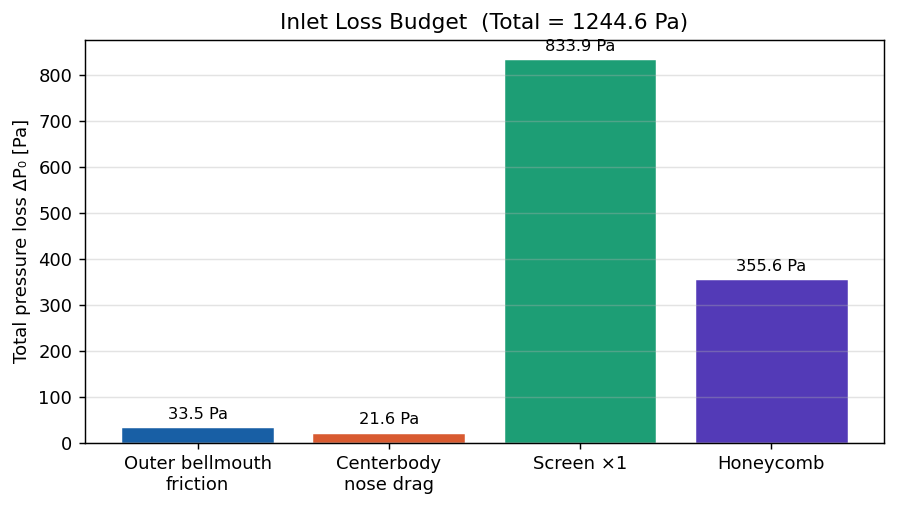

Total inlet ΔP₀       : 1244.6 Pa
As % of rotor ΔP₀     : 12.28%
As % of dynamic head  : 18.561%


In [7]:
sources = ['Outer bellmouth\nfriction', 'Centerbody\nnose drag',
           'Screen ×1', 'Honeycomb']
values  = [bell['dP0_bell_Pa'], bell['dP0_centerbody_Pa'],
           bell['dP0_screen_Pa'], bell['dP0_honey_Pa']]
colors  = ['#185FA5', '#D85A30', '#1D9E75', '#533AB7']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(sources, values, color=colors, edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%.1f Pa', padding=3, fontsize=9)
ax.set(ylabel='Total pressure loss ΔP₀ [Pa]',
       title=f'Inlet Loss Budget  (Total = {bell["dP0_total_Pa"]:.1f} Pa)')
ax.grid(True, axis='y', alpha=0.35)
plt.tight_layout()
plt.savefig(str(_root / 'figures') + '/04_loss_budget.png', dpi=130, bbox_inches='tight')
plt.show()

print(f'Total inlet ΔP₀       : {bell["dP0_total_Pa"]:.1f} Pa')
print(f'As % of rotor ΔP₀     : {bell["dP0_total_Pa"]/rotor["dP0_rotor_Pa"]*100:.2f}%')
print(f'As % of dynamic head  : {bell["zeta_total"]*100:.3f}%')

## 4. Settling section sensitivity

Show how turbulence intensity at the rotor face varies with contraction ratio.

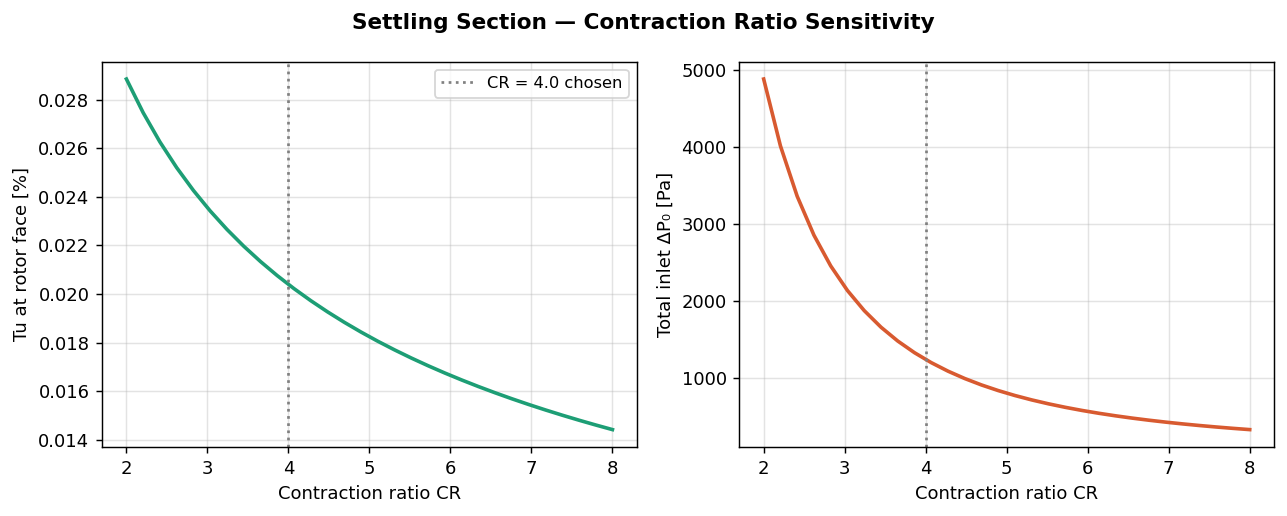

In [8]:
CR_range = np.linspace(2, 8, 30)
Tu_range = []
dP_range = []

for cr in CR_range:
    b = bellmouth_design(igv, contraction_ratio=cr)
    Tu_range.append(b['Tu_throat'] * 100)
    dP_range.append(b['dP0_total_Pa'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Settling Section — Contraction Ratio Sensitivity', fontweight='bold')

axes[0].plot(CR_range, Tu_range, '#1D9E75', lw=2)
axes[0].axvline(4.0, color='gray', ls=':', label='CR = 4.0 chosen')
axes[0].set(xlabel='Contraction ratio CR', ylabel='Tu at rotor face [%]')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.35)

axes[1].plot(CR_range, dP_range, '#D85A30', lw=2)
axes[1].axvline(4.0, color='gray', ls=':')
axes[1].set(xlabel='Contraction ratio CR', ylabel='Total inlet ΔP₀ [Pa]')
axes[1].grid(True, alpha=0.35)

plt.tight_layout()
plt.savefig(str(_root / 'figures') + '/04_settling_sensitivity.png', dpi=130, bbox_inches='tight')
plt.show()

## 5. Full axial station map

In [ ]:
stations_map = [
    ('Settling section entry',      bell['x_settle_entry_mm']),
    ('Centerbody nose tip',         bell['x_cb_nose_tip_mm']),
    ('Bellmouth lip (outer entry)', bell['x_bell_entry_mm']),
    ('ISO 5801 meas. plane',        bell['x_meas_mm']),
    ('Bellmouth exit / IGV LE',     bell['x_bell_exit_mm']),
    ('IGV trailing edge',           bell['x_igv_TE_mm']),
    ('Rotor leading edge',          bell['x_rotor_LE_mm']),
]

print('Axial station map  (x = 0 at rotor LE, upstream = negative)')
print('─' * 58)
for name, x in sorted(stations_map, key=lambda s: s[1]):
    print(f'  {name:<38}: x = {x:+8.1f} mm')
print(f'\nTotal inlet assembly length : {bell["L_inlet_total_mm"]:.0f} mm')

---
**Proceed to** `05_shaft_bearings_campbell.ipynb`.